# Множественная регрессия

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv")

In [14]:
x.head()

,0.07184119218267622,0.8553524138064769,-0.3055966142959303,0.028252569993086545,1.8268953710701943
0,0.139521,-0.423507,0.461059,-0.447400,-0.034988
1,1.626311,-0.257622,-0.697520,1.413219,1.086292
2,-1.183233,-0.826343,0.073047,-0.639690,-0.503273
3,-0.783365,-0.861232,0.951448,-0.117306,0.680597
4,3.077357,0.948615,-0.295527,1.390358,-0.116174


In [15]:
x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv",
                header=None)
y = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_y.csv",
                header=None)

0.7699743283650629


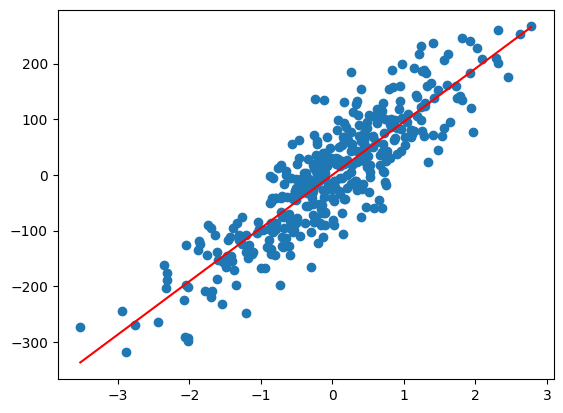

In [22]:
from sklearn.linear_model import LinearRegression

binary = LinearRegression()

binary.fit(x[[1]], y)

binary.coef_

binary.predict(x[[1]])

plt.scatter(x[1], y)

xx = np.linspace(x[1].min(), x[1].max(), 100).reshape((-1, 1))
plt.plot(xx, binary.predict(xx), c='r')

print(binary.score(x[[1]], y))


In [23]:
multiple = LinearRegression()
multiple.fit(x, y)
multiple.score(x, y)

0.9922198026415868

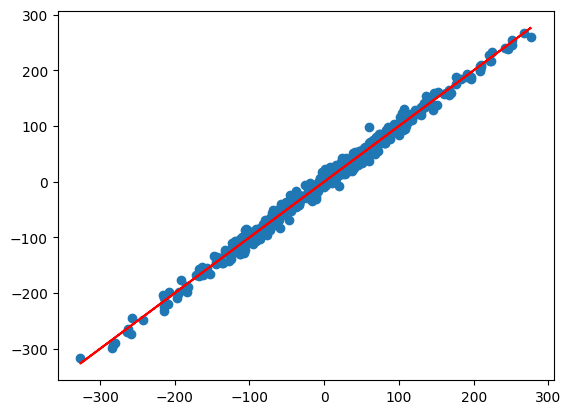

In [24]:
yy = multiple.predict(x)
plt.scatter(yy, y)
plt.plot(yy, yy, c='r')

# Для самостоятельного решения

## Задание 1: Парные регрессии от каждого атрибута

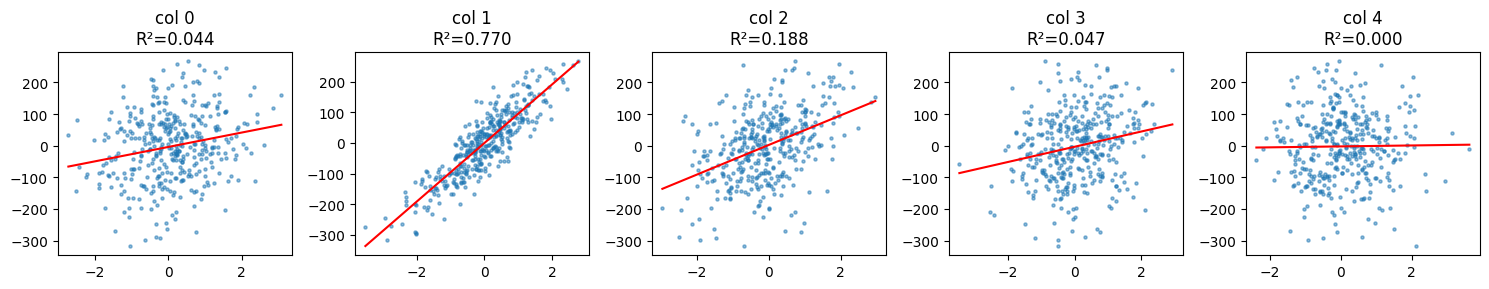

In [25]:
fig, axes = plt.subplots(1, x.shape[1], figsize=(15, 3))

for i, ax in enumerate(axes):
    m = LinearRegression()
    m.fit(x[[i]], y)
    xx = np.linspace(x[i].min(), x[i].max(), 100).reshape(-1, 1)
    ax.scatter(x[i], y, s=5, alpha=0.5)
    ax.plot(xx, m.predict(xx), 'r')
    ax.set_title(f"col {i}\nR²={m.score(x[[i]], y):.3f}")

plt.tight_layout()
plt.show()

## Задание 2*: Модель из предыдущей работы для произвольного числа столбцов

In [26]:
class MultipleLinearRegression:
    """Множественная линейная регрессия (градиентный спуск) для произвольного числа признаков."""

    def __init__(self):
        self.w = None  # веса (включая свободный член w[0])

    def predict(self, X):
        X = np.array(X)
        # добавляем столбец единиц для свободного члена
        Xb = np.column_stack([np.ones(len(X)), X])
        return Xb @ self.w

    def error(self, X, Y):
        return np.mean((self.predict(X) - np.array(Y).ravel()) ** 2) / 2

    def fit(self, X, Y, alpha=0.01, tol=1e-6, max_steps=10000):
        X, Y = np.array(X), np.array(Y).ravel()
        n, k = X.shape
        Xb = np.column_stack([np.ones(n), X])
        self.w = np.zeros(k + 1)

        prev_err = self.error(X, Y)
        for _ in range(max_steps):
            grad = Xb.T @ (Xb @ self.w - Y) / n
            self.w -= alpha * grad
            curr_err = self.error(X, Y)
            if abs(prev_err - curr_err) < tol:
                break
            prev_err = curr_err
        return self

    def score(self, X, Y):
        Y = np.array(Y).ravel()
        ss_res = np.sum((self.predict(X) - Y) ** 2)
        ss_tot = np.sum((Y - Y.mean()) ** 2)
        return 1 - ss_res / ss_tot


# Проверяем на всех 5 признаках
m_multi = MultipleLinearRegression().fit(x, y)
print(f"R² (наша модель): {m_multi.score(x, y):.4f}")
print(f"R² (sklearn):     {multiple.score(x, y):.4f}")

R² (наша модель): 0.9922
R² (sklearn):     0.9922


## Задание 3: Полиномиальная регрессия 2, 3, 10 порядков

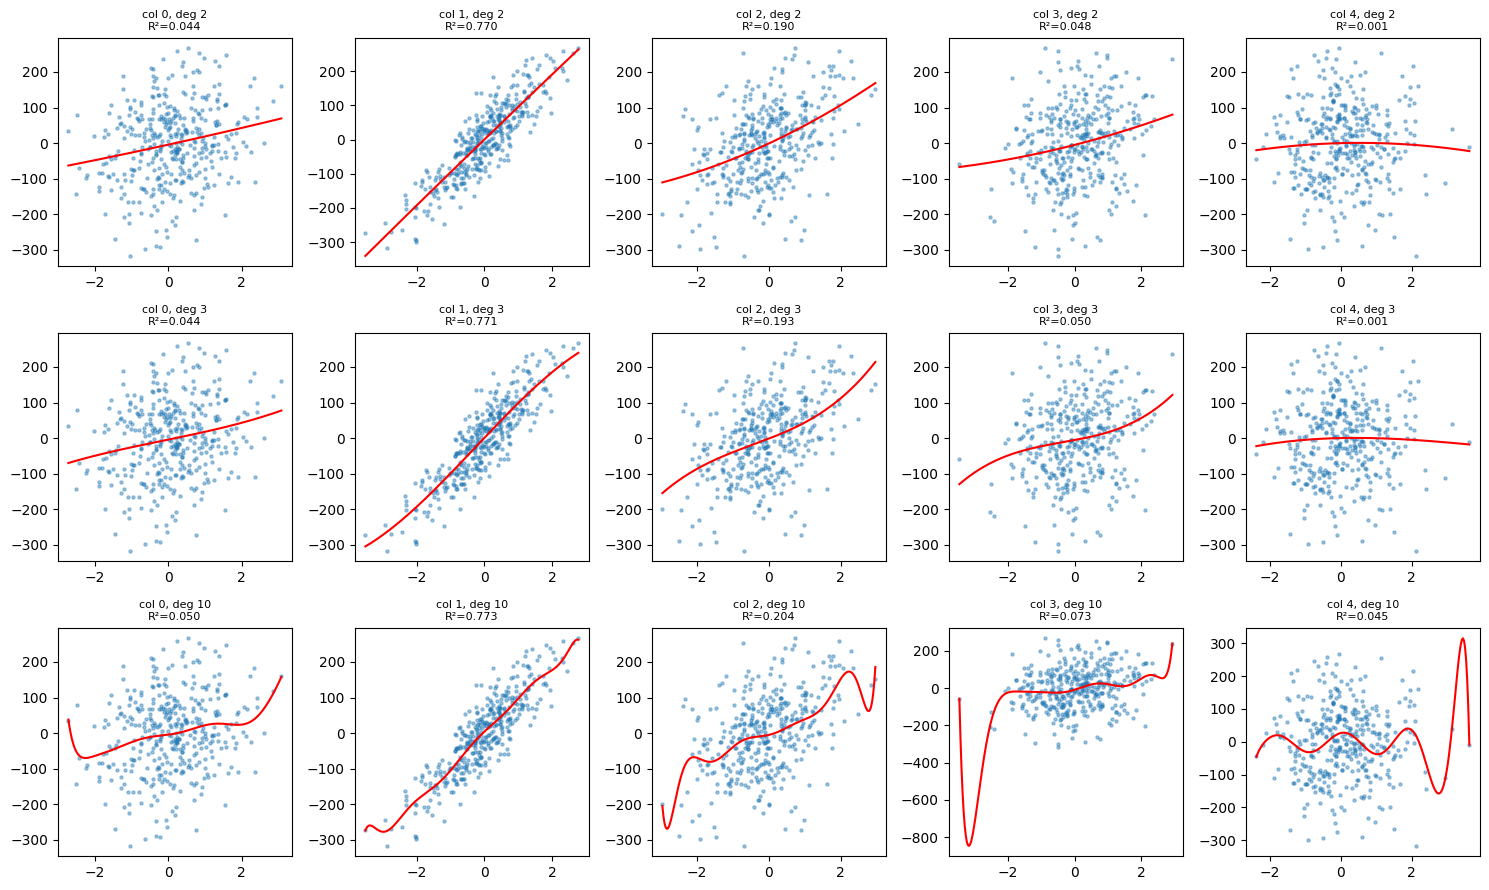

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = [2, 3, 10]
n_features = x.shape[1]

fig, axes = plt.subplots(len(degrees), n_features, figsize=(15, 9))

for row, deg in enumerate(degrees):
    for col in range(n_features):
        xi = x[[col]]
        model_poly = make_pipeline(PolynomialFeatures(deg), LinearRegression())
        model_poly.fit(xi, y)
        r2 = model_poly.score(xi, y)

        xx = np.linspace(xi.values.min(), xi.values.max(), 200).reshape(-1, 1)
        axes[row, col].scatter(xi, y, s=5, alpha=0.4)
        axes[row, col].plot(xx, model_poly.predict(xx), 'r')
        axes[row, col].set_title(f"col {col}, deg {deg}\nR²={r2:.3f}", fontsize=8)

plt.tight_layout()
plt.show()

## Задание 4: Сводная таблица точности всех моделей

In [28]:
rows = []

# Парные линейные регрессии
for col in range(n_features):
    m = LinearRegression().fit(x[[col]], y)
    rows.append({"модель": f"linear col{col}", "R²": m.score(x[[col]], y)})

# Множественная линейная
rows.append({"модель": "linear all", "R²": multiple.score(x, y)})

# Полиномиальные (парные)
for deg in degrees:
    for col in range(n_features):
        m = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(x[[col]], y)
        rows.append({"модель": f"poly{deg} col{col}", "R²": m.score(x[[col]], y)})

df_scores = pd.DataFrame(rows).set_index("модель")
df_scores["вывод"] = df_scores["R²"].apply(
    lambda r: "недообучена" if r < 0.5 else ("переобучена?" if r > 0.999 else "норм")
)
df_scores.round(4)

,R²,вывод
модель,,
linear col0,0.0436,недообучена
linear col1,0.7700,норм
linear col2,0.1879,недообучена
linear col3,0.0475,недообучена
linear col4,0.0002,недообучена
linear all,0.9922,норм
poly2 col0,0.0437,недообучена
poly2 col1,0.7700,норм
poly2 col2,0.1900,недообучена


## Задание 5: Дополнительные метрики качества

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "linear col0": LinearRegression().fit(x[[0]], y),
    "linear all":  multiple,
    "poly10 col0": make_pipeline(PolynomialFeatures(10), LinearRegression()).fit(x[[0]], y),
}

metrics = []
for name, m in models.items():
    xi = x[[0]] if "col0" in name else x
    yp = m.predict(xi)
    metrics.append({
        "модель": name,
        "R²":   r2_score(y, yp),
        "MAE":  mean_absolute_error(y, yp),       # средняя абсолютная ошибка
        "RMSE": mean_squared_error(y, yp) ** 0.5, # корень из среднеквадратичной
    })

pd.DataFrame(metrics).set_index("модель").round(4)

,R²,MAE,RMSE
модель,,,
linear col0,0.0436,85.7659,107.2019
linear all,0.9922,7.7807,9.6691
poly10 col0,0.0504,84.8542,106.8250


## Задание 6*: Время обучения полиномиальных моделей

        time_ms  n_features
degree                     
1         3.390           6
2         3.288          21
3         8.573          56
4         6.234         126
5        12.598         252
6        23.835         462
7        31.348         792
8        41.974        1287
9        60.047        2002
10       84.643        3003
11      111.903        4368


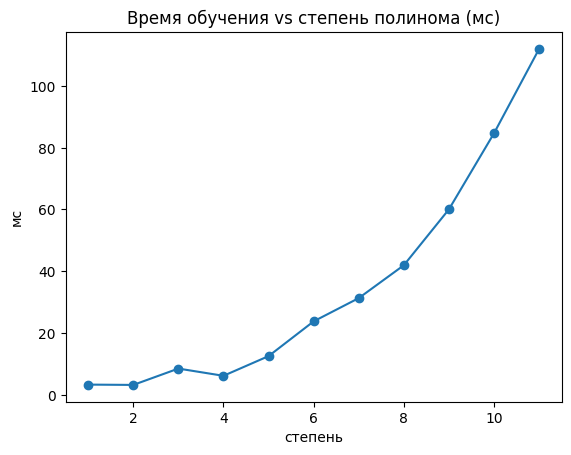

In [30]:
import time

timing = []
for deg in range(1, 12):
    m = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    t0 = time.perf_counter()
    m.fit(x, y)   # все 5 признаков
    elapsed = time.perf_counter() - t0
    n_features_poly = PolynomialFeatures(deg).fit_transform(x).shape[1]
    timing.append({"degree": deg, "time_ms": elapsed * 1000, "n_features": n_features_poly})

df_time = pd.DataFrame(timing).set_index("degree")
print(df_time.round(3))

df_time["time_ms"].plot(marker='o', title="Время обучения vs степень полинома (мс)")
plt.xlabel("степень")
plt.ylabel("мс")
plt.show()